### Project Overview: Titanic Survival Prediction & Hyperparameter tuning

#### Prepared By:
- Name: Abhishek Sahu
- Domain: Data Science
- ID : CT_CSI_DS_5981

This project aims to predict passenger survival on the Titanic using machine learning classification techniques. The dataset contains detailed information about passengers such as age, sex, class, fare, and family relationships. By analyzing these features, the goal is to build a model that can accurately classify whether a passenger survived or not.

Through exploratory data analysis (EDA), data cleaning, feature engineering, and model building, the project will uncover key patterns and predictors of survival. The final model will support accurate predictions on unseen data, demonstrating the use of data-driven approaches to understand historic events and solve real-world classification problems.

### Key Objectives:

- Perform EDA to understand data distributions, missing values, and feature relationships.

- Clean and preprocess data (handle missing values, encode categorical variables).

- Train and evaluate multiple classification models.

- Use metrics such as accuracy, precision, recall, and F1-score for evaluation.

- Apply hyperparameter tuning (GridSearchCV, RandomizedSearchCV) to optimize models.

- Select the best-performing model for final predictions.

### Dataset Metadata


| **Column Name** | **Description**                                                      | **Type**         | **Notes**                           |
| --------------- | -------------------------------------------------------------------- | ---------------- | ----------------------------------- |
| PassengerId     | Unique identifier for each passenger                                 | Numeric (int)    | Primary key; no predictive value    |
| Survived        | Survival outcome (0 = No, 1 = Yes)                                   | Numeric (binary) | **Target variable** (only in train) |
| Pclass          | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)                             | Ordinal (int)    | Socio-economic status               |
| Name            | Passenger’s name                                                     | String           | Can be used for feature engineering |
| Sex             | Gender of passenger                                                  | Categorical      | Important predictive feature        |
| Age             | Age in years                                                         | Numeric (float)  | Has missing values                  |
| SibSp           | Number of siblings/spouses aboard                                    | Numeric (int)    | Family relationship info            |
| Parch           | Number of parents/children aboard                                    | Numeric (int)    | Family relationship info            |
| Ticket          | Ticket number                                                        | String           | Often dropped, or engineered        |
| Fare            | Passenger fare                                                       | Numeric (float)  | Skewed, useful for income proxy     |
| Cabin           | Cabin number                                                         | String           | Many missing values                 |
| Embarked        | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) | Categorical      | Has a few missing values            |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [30]:
train_df=pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week6_Task\train.csv")
test_df=pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Week6_Task\test.csv")

### Data profiling

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
train_df.shape

(891, 12)

In [7]:
test_df.shape

(418, 11)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [83]:
train_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [9]:
test_df.nunique()

PassengerId    418
Pclass           3
Name           418
Sex              2
Age             79
SibSp            7
Parch            8
Ticket         363
Fare           169
Cabin           76
Embarked         3
dtype: int64

In [10]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [87]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [13]:
train_df.describe(include='O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


### Data Preprocessing

In [14]:
train_df.duplicated().sum()

0

In [15]:
test_df.duplicated().sum()

0

In [5]:
nv = train_df.isna().sum().sort_values(ascending=False)
nv

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [6]:
nv1 = test_df.isna().sum().sort_values(ascending=False)
nv1

Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Embarked         0
dtype: int64

In [32]:
train_df.drop(columns = 'Cabin', axis = 1, inplace = True)
test_df.drop(columns = 'Cabin', axis = 1, inplace = True)

In [33]:
train_df['Age'].fillna(train_df['Age'].mean(),inplace=True)
test_df['Age'].fillna(test_df['Age'].mean(),inplace=True)

train_df['Embarked'].fillna(train_df['Embarked'].mode()[0],inplace=True)
test_df=test_df.ffill()

In [9]:
train_df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
test_df.isna().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

#### Feature selection

In [23]:
train_df['Survived'].unique()

array([0, 1], dtype=int64)

In [11]:
for col in train_df.columns:
    print(f"\nColumn: {col}")
    print(train_df[col].unique())



Column: PassengerId
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 2

In [35]:
train_df.drop(columns=['PassengerId','Name','Ticket'],axis=1,inplace=True)
test_df.drop(columns=['PassengerId','Name','Ticket'],axis=1,inplace=True)
train_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [13]:
for col in train_df.columns:
    print(f"\nColumn: {col}")
    print(train_df[col].unique())


Column: Survived
[0 1]

Column: Pclass
[3 1 2]

Column: Sex
['male' 'female']

Column: Age
[22.         38.         26.         35.         29.69911765 54.
  2.         27.         14.          4.         58.         20.
 39.         55.         31.         34.         15.         28.
  8.         19.         40.         66.         42.         21.
 18.          3.          7.         49.         29.         65.
 28.5         5.         11.         45.         17.         32.
 16.         25.          0.83       30.         33.         23.
 24.         46.         59.         71.         37.         47.
 14.5        70.5        32.5        12.          9.         36.5
 51.         55.5        40.5        44.          1.         61.
 56.         50.         36.         45.5        20.5        62.
 41.         52.         63.         23.5         0.92       43.
 60.         10.         64.         13.         48.          0.75
 53.         57.         80.         70.         24.5       

#### Data visualization

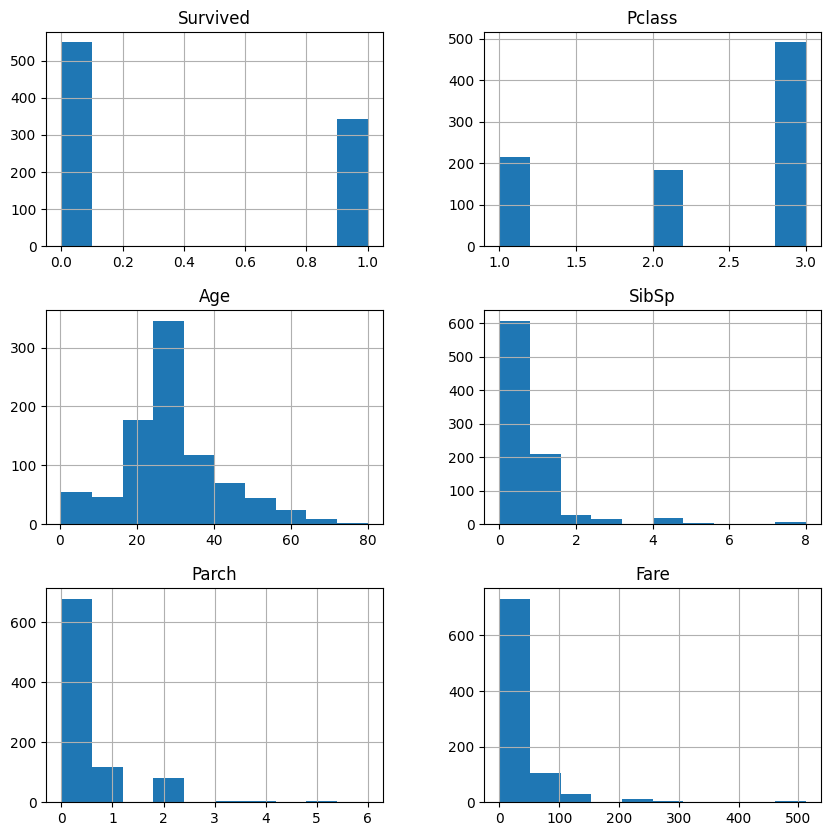

In [14]:
train_df.hist(figsize=(10,10))
plt.show()

<Axes: xlabel='Survived', ylabel='count'>

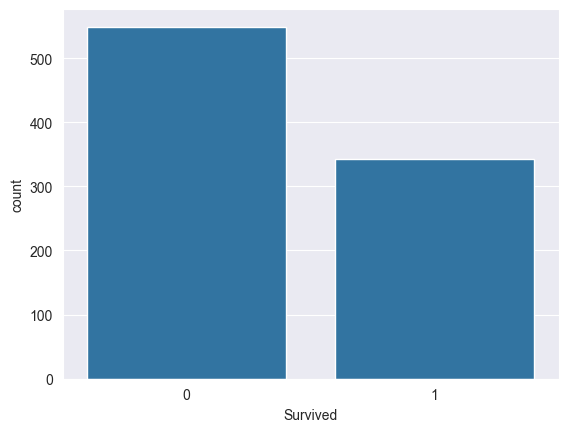

In [106]:
sns.set_style("darkgrid")
sns.countplot(x="Survived", data=train_df)

This plot Clearly shows most people are died

<Axes: xlabel='Pclass', ylabel='count'>

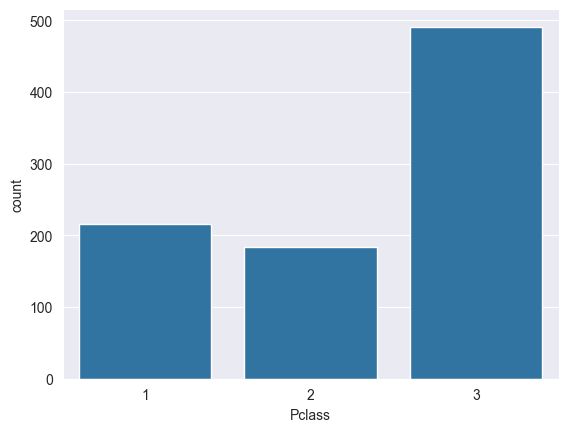

In [107]:
sns.countplot(x="Pclass", data=train_df)

In [108]:
cat_cols = train_df.select_dtypes(include='object').columns
cat_cols

Index(['Sex', 'Embarked'], dtype='object')

Sex
male      577
female    314
Name: count, dtype: int64


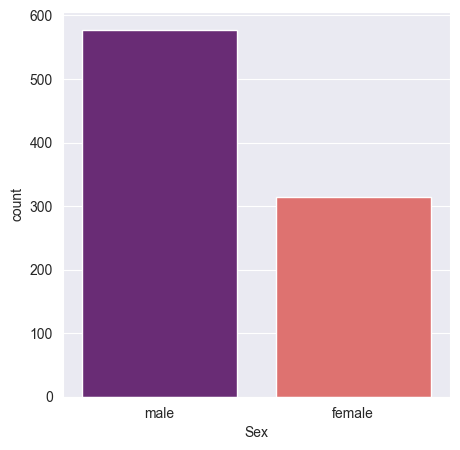

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


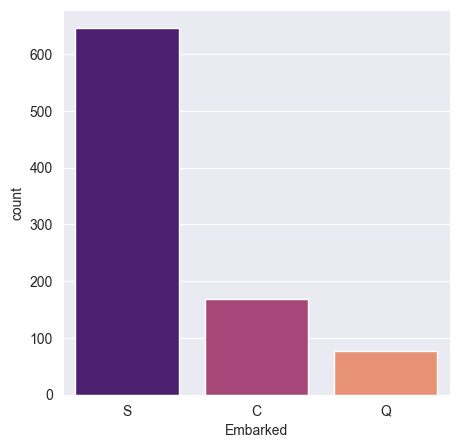

In [109]:
for i in cat_cols:
    print(train_df[i].value_counts())
    plt.figure(figsize=(5,5))
    sns.countplot(x=train_df[i],palette='magma')
    plt.xlabel(i)
    plt.show()

Plot clearly shows that most of the people choose Southampton as their port of embarkation.

<Axes: xlabel='Survived', ylabel='count'>

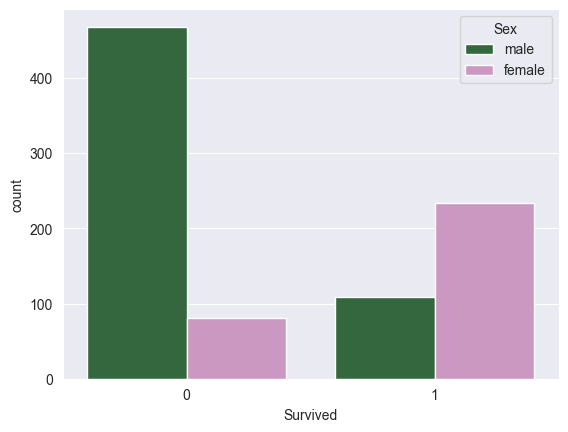

In [110]:
sns.countplot(x="Survived", hue="Sex", data=train_df, palette="cubehelix")

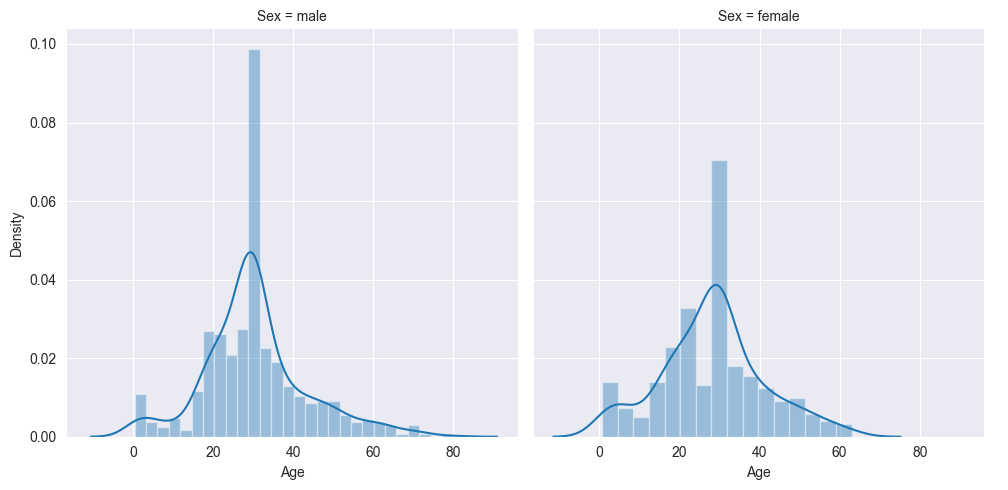

In [111]:
d1 = sns.FacetGrid(train_df, col="Sex",height=5)
d1 = (d1.map(sns.distplot, "Age").add_legend())

We can see proportion of both males and females are generally lies between 20-40 age group

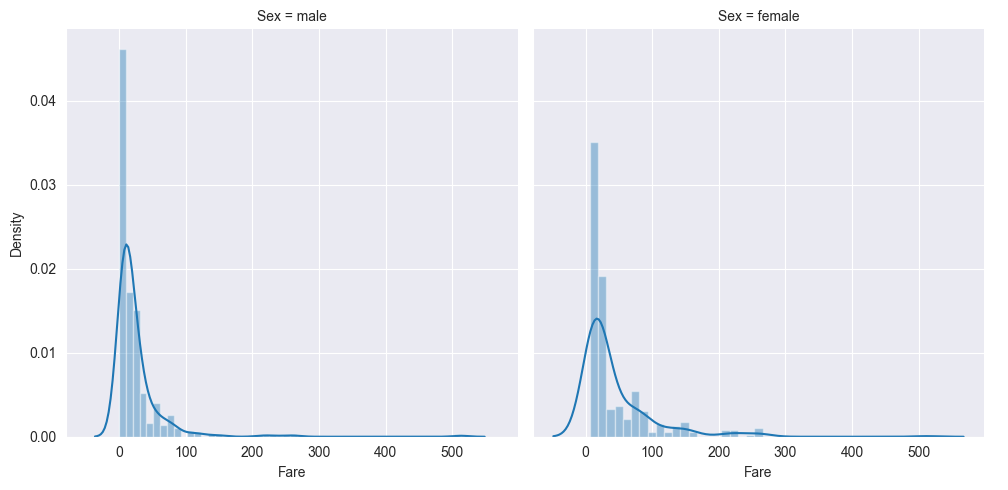

In [112]:
d2 = sns.FacetGrid(train_df, col="Sex",height=5)
d2 = (d2.map(sns.distplot, "Fare").add_legend())

From the Plot we can see that for both the genders , the price of the ticket are generally lies between 0 to 100. But, the density of the ticket is more for males.

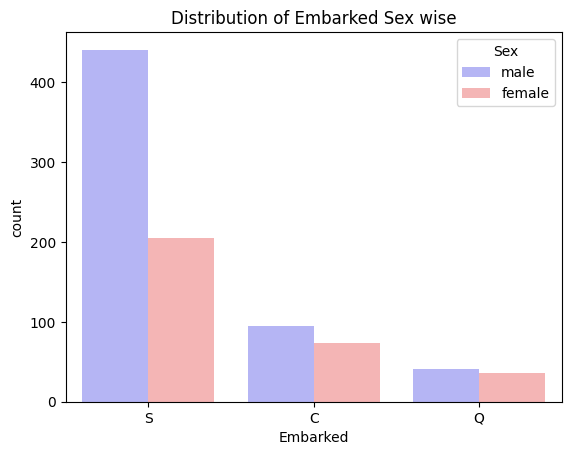

In [15]:
sns.countplot(x=train_df['Embarked'],hue=train_df['Sex'],palette='bwr')
plt.title('Distribution of Embarked Sex wise')
plt.show()

We can Clearly see both kind of peoples either males or females mostly choose Southampton as their port of embarkation.

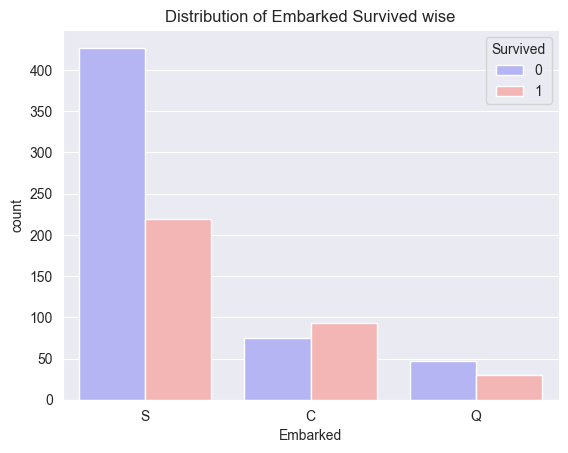

In [114]:
sns.countplot(x=train_df['Embarked'],hue=train_df['Survived'],palette='bwr')
plt.title('Distribution of Embarked Survived wise')
plt.show()

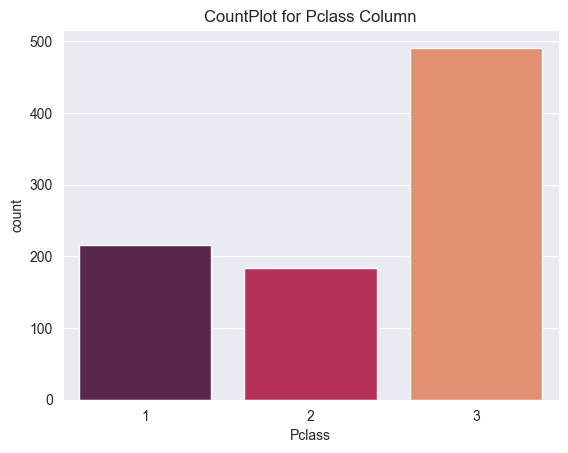

In [115]:
sns.countplot(x=train_df['Pclass'],palette='rocket')
plt.title('CountPlot for Pclass Column')
plt.show()

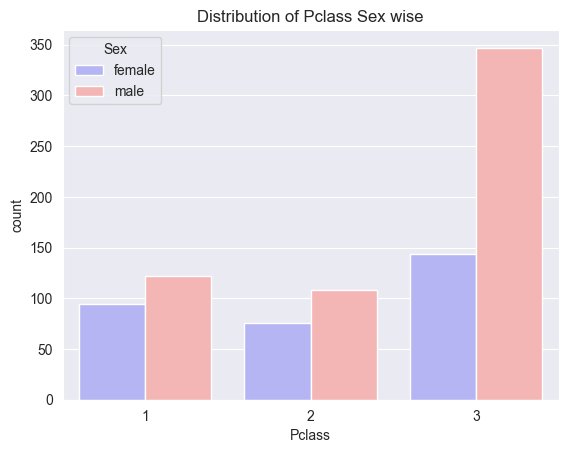

In [116]:
sns.countplot(x=train_df['Pclass'],hue=train_df['Sex'],palette='bwr')
plt.title('Distribution of Pclass Sex wise')
plt.show()

In [16]:
data=train_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
data.corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


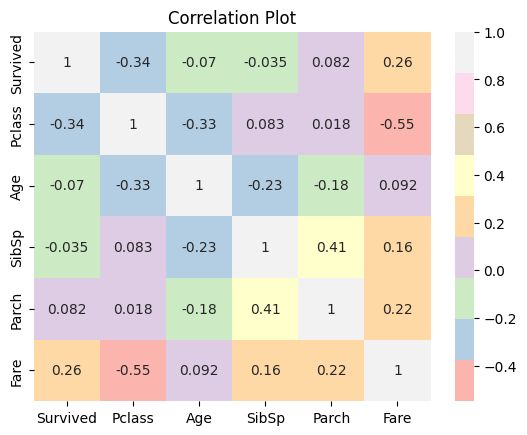

In [17]:
sns.heatmap(data.corr(),annot=True,cmap='Pastel1')
plt.title('Correlation Plot')
plt.show()

### Training multiple models

In [14]:
from sklearn.metrics import accuracy_score

In [15]:
train_df.loc[train_df['Sex'] == 'male', 'Sex',] = 1
train_df.loc[train_df['Sex'] == 'female', 'Sex',] = 0
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [16]:
train_df.shape , test_df.shape

((891, 8), (418, 7))

In [17]:
x =train_df.drop(columns=['Embarked', 'Survived'])
y =train_df["Survived"]

In [18]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

#### Logistic Regression

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=7, stratify=y)
lr_model=LogisticRegression()

In [24]:
lr_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_valid)

In [25]:
y_pred[0:10]

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [26]:
y_valid[0:10]

7      0
874    1
720    1
513    1
459    0
451    0
218    1
219    0
680    0
204    1
Name: Survived, dtype: int64

In [27]:
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       110
           1       0.71      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179

[[91 19]
 [23 46]]


In [28]:
accuracy=accuracy_score(y_valid,y_pred)
accuracy

0.7653631284916201

#### KNN classifier

In [54]:
from sklearn.neighbors import KNeighborsClassifier
accuracy_array=[]
best_accuracy=0  
best_k=0
ks=range(2,int(len(x_train)/2))

for k in ks:
    model_knn=KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(x_train,y_train)
    y_pred=model_knn.predict(x_valid)
    accuracy=accuracy_score(y_valid,y_pred)
    accuracy_array.append(accuracy)
    if accuracy>best_accuracy:
        best_accuracy=accuracy
        best_k=k
print("best_k",best_k)
print("best_accuracy",best_accuracy)

best_k 34
best_accuracy 0.7374301675977654


In [55]:
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.64      1.00      0.78       110
           1       1.00      0.09      0.16        69

    accuracy                           0.65       179
   macro avg       0.82      0.54      0.47       179
weighted avg       0.78      0.65      0.54       179

[[110   0]
 [ 63   6]]


#### Random Forest

In [48]:
rf_model=RandomForestClassifier()
rf_model.fit(x_train, y_train) 

RandomForestClassifier()

In [60]:
y_pred = rf_model.predict(x_valid)
y_pred[0:10]

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 0], dtype=int64)

In [61]:
y_valid[0:10]

7      0
874    1
720    1
513    1
459    0
451    0
218    1
219    0
680    0
204    1
Name: Survived, dtype: int64

In [62]:
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

[[96 14]
 [19 50]]


In [63]:
accuracy=accuracy_score(y_valid,y_pred)
accuracy

0.8156424581005587

#### Gradient Boosting

In [56]:
gb_model=GradientBoostingClassifier()
gb_model.fit(x_train, y_train) 

GradientBoostingClassifier()

In [64]:
y_pred = gb_model.predict(x_valid)
y_pred[0:10]

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 0], dtype=int64)

In [65]:
y_valid[0:10]

7      0
874    1
720    1
513    1
459    0
451    0
218    1
219    0
680    0
204    1
Name: Survived, dtype: int64

In [66]:
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

[[97 13]
 [19 50]]


In [67]:
accuracy=accuracy_score(y_valid,y_pred)
accuracy

0.8212290502793296

### Hyperparameter Tuning

##### RandomForestClassifier

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

# Evaluate on validation set
best_model = grid.best_estimator_
y_pred = best_model.predict(x_valid)
print(classification_report(y_valid, y_pred))
print(accuracy_score(y_valid,y_pred))

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best score: 0.8315177779966512
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       110
           1       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

0.8324022346368715


In [22]:
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': randint(2, 10),
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_)


Best parameters: {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 171}
Best score: 0.8357332808037035


##### GradientBoostingClassifier

In [72]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit to training data
grid_search.fit(x_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Best estimator
best_gbc = grid_search.best_estimator_
# Predict on validation set
y_pred = best_gbc.predict(x_valid)

print(classification_report(y_valid, y_pred))
print("Accuracy:", accuracy_score(y_valid, y_pred))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV Score: 0.8427065891854625
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy: 0.8212290502793296


In [29]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distributions
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.6, 0.8, 1.0]
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit to training data
random_search.fit(x_train, y_train)

# Best hyperparameters
print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

# Best estimator
best_gbc = random_search.best_estimator_

# Predict on validation set
y_pred = best_gbc.predict(x_valid)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_valid, y_pred))
print(classification_report(y_valid, y_pred))
print("Accuracy:", accuracy_score(y_valid, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score: 0.8399290849995076
[[97 13]
 [19 50]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy: 0.8212290502793296


#### Making prediction on the best model

In [38]:
# Use best model
best_rf = random_search.best_estimator_

# Predict on test set
#test_df = test_df.drop(columns=['Embarked'])
test_df.loc[test_df['Sex'] == 'male', 'Sex',] = 1
test_df.loc[test_df['Sex'] == 'female', 'Sex',] = 0

test_predictions = best_rf.predict(test_df)

# Create submission DataFrame
submission = pd.DataFrame({           
    'Prediction': test_predictions
})

# Save as CSV
submission.to_csv('final_rf_predictions.csv', index=False)

print("✅ Submission file created successfully!")


✅ Submission file created successfully!


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       110
           1       0.84      0.71      0.77        69

    accuracy                           0.84       179
   macro avg       0.84      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179



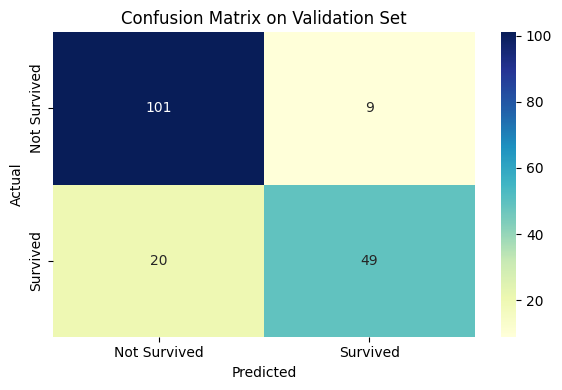

✅ Validation Accuracy: 0.8380


In [39]:
# Predict on validation set
y_pred = best_rf.predict(x_valid)

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_valid, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix on Validation Set")
plt.tight_layout()
plt.show()

# Accuracy
acc = accuracy_score(y_valid, y_pred)
print(f"✅ Validation Accuracy: {acc:.4f}")

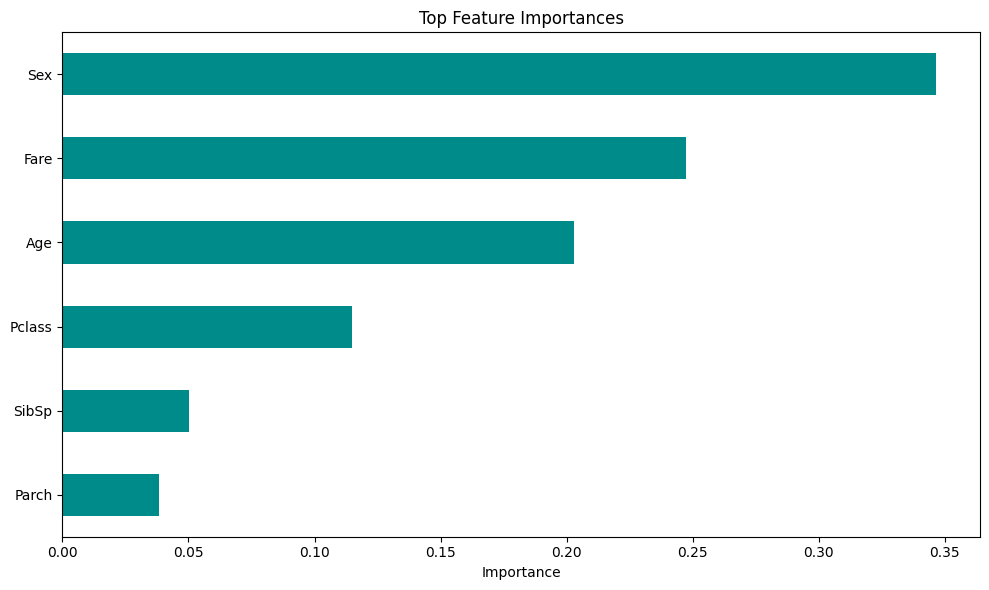

In [41]:
importances = best_rf.feature_importances_

# Create a series with feature names
feat_importance = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.head(20).plot(kind='barh', color='darkcyan')
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()